# Causal Conv1D — Subject 0 · GNG Clean · LOTO CV

Same preprocessing pipeline as `eeg_lgb_focused.ipynb` (ICA-cleaned data,
despike, skip, CAR, bandpass, trial z-score, HORIZON=2.5 s, post-press blanking).

**Input**: raw EEG windows `(B, C, T)` — no hand-crafted features.  
**Model**: stacked causal Conv1D → global avg pool → linear head.  
**CV**: LOTO (leave-one-trial-out), same structure as LGB focused.  
**Goal**: compare event-level detection metrics side-by-side with LGB.

In [1]:
%matplotlib inline
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve
from torch.utils.data import DataLoader, TensorDataset

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT))

from preprocessing import load_trial, make_horizon_labels, make_post_press_mask
from src.model.conv1d import DSCausalConv1D
from src.postproc import event_detection_metrics, persistence_gate

DARK = "#0a0e17"
CARD = "#111827"
EDGE = "#1f2937"
TEAL = "#00e5cc"
CORAL = "#ff4f5e"
GOLD = "#ffc947"
WHITE = "#f0f4ff"

In [2]:
# ── Data (match lgb_focused) ──────────────────────────────────────────────────
SUBJECT = 0
TACHE = "gng_clean"
ALL_TRIALS = list(range(1, 10))
TEST_TRIALS = list(range(1, 10))
DATA_PATH = f"../data/subject{SUBJECT}/"

# Auto-detect FS from first trial timestamp column
_first = f"../data/subject{SUBJECT}/subject_{SUBJECT}_tache_{TACHE}_trial_0.csv"
_ts = pd.read_csv(_first, sep=None, engine="python", usecols=["timestamp"])[
    "timestamp"
].values
FS_RAW = round(len(_ts) / (_ts[-1] - _ts[0]))
DECIM = 4 if FS_RAW >= 100 else 1
FS = FS_RAW
FS_EFF = FS // DECIM

# ── Preprocessing (identical to lgb_focused) ──────────────────────────────────
LP, HP = 0.5, 8.0
DESPIKE_SIGMA = 5.0
SKIP_SECONDS = 20.0
HORIZON = int(2.5 * FS_EFF)
REFRACTORY = int(1.0 * FS_EFF)
SMOOTH_WIN = max(1, int(0.1 * FS_EFF))
PERSIST_K = 10
POST_PRESS_BLANK_MS = 1500
MIN_SPEC = 0.95
TARGET_EVT_SENS = 0.70

# ── Fixed DSCausalConv1D hyperparameters ──────────────────────────────────────
T_OPT = int(2.5 * FS_EFF)  # 2.5 s = full horizon window
N_FILTERS = 32  # output filters of first block
N_LAYERS = 3  # number of DS blocks
KERNEL_SIZE = 7  # temporal kernel per depthwise conv
DEPTH_MULT = 2  # D temporal filters per channel (depthwise)
GROW_FILTERS = True  # 32 → 64 → 128 across blocks
DROPOUT = 0.3
USE_BN = True
ACTIVATION = "gelu"
LR = 1e-3
WEIGHT_DECAY = 1e-4
BATCH_SIZE = 256
MAX_EPOCHS = 120
PATIENCE = 10
SEED = 42

# ── Data augmentation (training only) ────────────────────────────────────────
USE_AUG = True
NOISE_STD = 0.05
CH_DROPOUT = 0.15
JITTER_SAMP = max(1, int(0.1 * FS_EFF))  # ±100 ms

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = (
    "mps"
    if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"FS_RAW={FS_RAW}  DECIM={DECIM}  FS_EFF={FS_EFF} Hz")
print(
    f"T_OPT={T_OPT} ({T_OPT/FS_EFF*1000:.0f} ms)  "
    f"HORIZON={HORIZON} ({HORIZON/FS_EFF*1000:.0f} ms)  "
    f"blank={POST_PRESS_BLANK_MS} ms  persist_k={PERSIST_K}"
)
print(f"Device: {DEVICE}")
print(
    f"Architecture: DSCausalConv1D  {N_LAYERS} blocks × ({N_FILTERS} filters, D={DEPTH_MULT})  "
    f"grow={GROW_FILTERS}  k={KERNEL_SIZE}  drop={DROPOUT}  BN={USE_BN}  {ACTIVATION}"
)
print(
    f"Augmentation: noise_std={NOISE_STD}  ch_dropout={CH_DROPOUT}  "
    f"jitter=±{JITTER_SAMP} samp (±{JITTER_SAMP/FS_EFF*1000:.0f} ms)"
)

FS_RAW=243  DECIM=4  FS_EFF=60 Hz
T_OPT=150 (2500 ms)  HORIZON=150 (2500 ms)  blank=1500 ms  persist_k=10
Device: mps
Architecture: DSCausalConv1D  3 blocks × (32 filters, D=2)  grow=True  k=7  drop=0.3  BN=True  gelu
Augmentation: noise_std=0.05  ch_dropout=0.15  jitter=±6 samp (±100 ms)


In [3]:
# ── Load all trials, build sliding windows ────────────────────────────────────
blank_samp = int(POST_PRESS_BLANK_MS / 1000 * FS_EFF)

X_list, y_list, ymom_list, tid_list, pp_list = [], [], [], [], []

for trial_n in ALL_TRIALS:
    try:
        df, cols = load_trial(
            subject=SUBJECT,
            tache=TACHE,
            trial=trial_n,
            data_path=DATA_PATH,
            fs=FS,
            lp=LP,
            hp=HP,
            apply_filter=True,
            car=True,
            trial_zscore=True,
            clip_percentile=1.0,
            decimate=DECIM,
            despike_sigma=DESPIKE_SIGMA,
            skip_seconds=SKIP_SECONDS,
        )
    except FileNotFoundError:
        print(f"  trial {trial_n}: not found — skipping")
        continue

    X = df[cols].values.astype(np.float32)  # (N, C)
    y_mom = df["button"].values.astype(np.int64)  # (N,)
    y_h = make_horizon_labels(y_mom, HORIZON)  # (N,)
    pp = make_post_press_mask(y_mom, blank_samp)  # (N,)
    N = len(X)

    wins = np.stack([X[i - T_OPT : i] for i in range(T_OPT, N)])  # (M, T, C)
    X_list.append(wins)
    y_list.append(y_h[T_OPT:].astype(np.float32))
    ymom_list.append(y_mom[T_OPT:].astype(np.int64))
    tid_list.append(np.full(N - T_OPT, trial_n, dtype=np.int32))
    pp_list.append(pp[T_OPT:])

    n_pos = int(y_h[T_OPT:].sum())
    M = N - T_OPT
    print(
        f"  trial {trial_n}: {N} samp  {int(y_mom.sum())} presses  "
        f"pos={n_pos}/{M} ({n_pos/M:.1%})"
    )

X_all = np.concatenate(X_list, axis=0)  # (M_total, T, C)
y_all = np.concatenate(y_list, axis=0)  # (M_total,)
ymom_all = np.concatenate(ymom_list, axis=0)  # (M_total,)
tid_all = np.concatenate(tid_list, axis=0)
pp_all = np.concatenate(pp_list, axis=0)
N_CH = X_all.shape[2]

print(
    f"\nTotal: {len(X_all)} windows  shape={X_all.shape}  "
    f"pos={y_all.mean():.2%}  channels={N_CH}"
)

  trial 1: 15452 samp  30 presses  pos=4390/15302 (28.7%)
  trial 2: 15864 samp  28 presses  pos=4086/15714 (26.0%)
  trial 3: 15669 samp  27 presses  pos=3900/15519 (25.1%)
  trial 4: 15303 samp  30 presses  pos=4350/15153 (28.7%)
  trial 5: 15438 samp  29 presses  pos=4200/15288 (27.5%)
  trial 6: 15093 samp  30 presses  pos=4350/14943 (29.1%)
  trial 7: 15037 samp  30 presses  pos=4350/14887 (29.2%)
  trial 8: 15207 samp  29 presses  pos=4350/15057 (28.9%)
  trial 9: 15200 samp  29 presses  pos=4350/15050 (28.9%)

Total: 136913 windows  shape=(136913, 150, 16)  pos=27.99%  channels=16


In [4]:
# ── Training & inference helpers ──────────────────────────────────────────────


class AugDataset(torch.utils.data.Dataset):
    """
    (M, T, C) windows with on-the-fly training augmentations:
      1. Additive Gaussian noise
      2. Channel dropout (zero entire channels)
      3. Temporal jitter (roll ± JITTER_SAMP, zero-pad boundary)
    """

    def __init__(self, X_np: np.ndarray, y_np: np.ndarray, augment: bool = False):
        self.X = torch.from_numpy(X_np.astype(np.float32))  # (M, T, C)
        self.y = torch.from_numpy(y_np.astype(np.float32))
        self.augment = augment
        self.C = X_np.shape[2]

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].clone()  # (T, C)
        if self.augment:
            x = x + NOISE_STD * torch.randn_like(x)
            ch_mask = (torch.rand(self.C) > CH_DROPOUT).float()
            x = x * ch_mask.unsqueeze(0)
            if JITTER_SAMP > 0:
                shift = int(torch.randint(-JITTER_SAMP, JITTER_SAMP + 1, (1,)).item())
                if shift != 0:
                    x = torch.roll(x, shift, dims=0)
                    if shift > 0:
                        x[:shift, :] = 0.0
                    else:
                        x[shift:, :] = 0.0
        return x.T, self.y[idx]  # (C, T), scalar


def make_loader(X_np, y_np, batch_size, shuffle, augment=False):
    ds = AugDataset(X_np, y_np, augment=augment)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)


def train_fold(X_tr, y_tr, X_val, y_val, device):
    """Train DSCausalConv1D; early-stop on val AUC. Returns (model, best_val_auc)."""
    n_pos = float(y_tr.sum())
    n_neg = float(len(y_tr)) - n_pos
    pos_w = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32).to(device)

    model = DSCausalConv1D(
        in_channels=N_CH,
        n_filters=N_FILTERS,
        n_layers=N_LAYERS,
        kernel_size=KERNEL_SIZE,
        depth_mult=DEPTH_MULT,
        grow_filters=GROW_FILTERS,
        dropout_rate=DROPOUT,
        activation=ACTIVATION,
        use_bn=USE_BN,
    ).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=MAX_EPOCHS)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    loader_tr = make_loader(X_tr, y_tr, BATCH_SIZE, shuffle=True, augment=USE_AUG)

    best_auc, best_state, no_imp = 0.0, None, 0

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        for Xb, yb in loader_tr:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            criterion(model(Xb), yb).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
        scheduler.step()

        model.eval()
        with torch.no_grad():
            Xv = torch.from_numpy(X_val.transpose(0, 2, 1)).to(device)
            sc = torch.sigmoid(model(Xv)).cpu().numpy()
        try:
            auc = roc_auc_score(y_val, sc)
        except Exception:
            auc = 0.5
        if auc > best_auc:
            best_auc = auc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
        if no_imp >= PATIENCE:
            break

    model.load_state_dict(best_state)
    return model, best_auc


@torch.no_grad()
def predict(model, X_np, device, batch_size=2048):
    model.eval()
    scores = []
    loader = make_loader(
        X_np,
        np.zeros(len(X_np), dtype=np.float32),
        batch_size,
        shuffle=False,
        augment=False,
    )
    for Xb, _ in loader:
        scores.append(torch.sigmoid(model(Xb.to(device))).cpu().numpy())
    return np.concatenate(scores)


def thresh_at_spec(fpr, tpr, thresholds, min_spec=MIN_SPEC):
    for spec in [min_spec, 0.90, 0.85, 0.80, 0.70]:
        valid = (1 - fpr) >= spec
        if valid.any() and tpr[valid].max() > 0:
            if spec < min_spec:
                print(f"    [thresh] relaxed spec {min_spec:.0%}→{spec:.0%}")
            return float(thresholds[np.argmax(tpr[valid])])
    return float(thresholds[np.argmax(tpr - fpr)])


def smooth_scores(scores, window=SMOOTH_WIN):
    if window <= 1:
        return scores.copy()
    return (
        pd.Series(scores)
        .rolling(window, min_periods=1)
        .mean()
        .values.astype(np.float32)
    )


_demo = DSCausalConv1D(
    16,
    N_FILTERS,
    N_LAYERS,
    KERNEL_SIZE,
    DEPTH_MULT,
    GROW_FILTERS,
    DROPOUT,
    ACTIVATION,
    USE_BN,
)
total_params = sum(p.numel() for p in _demo.parameters())
print(
    f"DSCausalConv1D ready  — {total_params:,} parameters  "
    f"(vs 76,065 for standard Conv1D)"
)

DSCausalConv1D ready  — 24,545 parameters  (vs 76,065 for standard Conv1D)


In [5]:
# ── LOTO CV ───────────────────────────────────────────────────────────────────
scores_raw = np.zeros(len(y_all), dtype=np.float32)
fold_results = []

for test_trial in TEST_TRIALS:
    te = tid_all == test_trial
    tr = ~te

    # Post-press blanking on training negatives (same as lgb_focused)
    keep = (y_all[tr] == 1) | ~pp_all[tr]
    X_tr = X_all[tr][keep]  # (N_tr_clean, T, C)
    y_tr = y_all[tr][keep]
    X_te = X_all[te]
    y_te = y_all[te]

    # Temporal val split: last 15% of cleaned training data
    n_val = max(64, int(0.15 * len(X_tr)))
    X_val = X_tr[-n_val:]
    y_val = y_tr[-n_val:]
    X_tr_f = X_tr[:-n_val]
    y_tr_f = y_tr[:-n_val]

    print(
        f"Fold trial={test_trial}  "
        f"train={len(X_tr_f)} (pos={y_tr_f.mean():.1%})  "
        f"val={len(X_val)}  "
        f"test={len(X_te)} (pos={y_te.mean():.1%})",
        flush=True,
    )

    model, val_auc = train_fold(X_tr_f, y_tr_f, X_val, y_val, DEVICE)

    # Threshold at MIN_SPEC specificity on full training fold
    sc_tr = predict(model, X_tr, DEVICE)
    fpr_t, tpr_t, thr_t = roc_curve(y_tr, sc_tr)
    thresh_f = thresh_at_spec(fpr_t, tpr_t, thr_t)

    # Test inference
    sc_te = predict(model, X_te, DEVICE)
    scores_raw[te] = sc_te

    auc = roc_auc_score(y_te, sc_te)
    ap = average_precision_score(y_te, sc_te)
    fold_results.append(
        dict(trial=test_trial, auc=auc, ap=ap, thresh=thresh_f, val_auc=val_auc)
    )
    print(
        f"  → val_AUC={val_auc:.4f}  AUC={auc:.4f}  AP={ap:.4f}  "
        f"thresh={thresh_f:.3f}\n"
    )

print("LOTO complete.")

Fold trial=1  train=86156 (pos=33.5%)  val=15204  test=15302 (pos=28.7%)
  → val_AUC=0.6748  AUC=0.5549  AP=0.3549  thresh=0.991

Fold trial=2  train=85731 (pos=34.0%)  val=15128  test=15714 (pos=26.0%)
  → val_AUC=0.7405  AUC=0.6532  AP=0.3195  thresh=0.965

Fold trial=3  train=85763 (pos=34.2%)  val=15134  test=15519 (pos=25.1%)
  → val_AUC=0.7193  AUC=0.6756  AP=0.3551  thresh=0.463

Fold trial=4  train=86306 (pos=33.5%)  val=15230  test=15153 (pos=28.7%)
  → val_AUC=0.7406  AUC=0.5665  AP=0.3216  thresh=0.965

Fold trial=5  train=86093 (pos=33.7%)  val=15192  test=15288 (pos=27.5%)
  → val_AUC=0.7130  AUC=0.6755  AP=0.3886  thresh=0.958

Fold trial=6  train=86462 (pos=33.4%)  val=15257  test=14943 (pos=29.1%)
  → val_AUC=0.7107  AUC=0.6256  AP=0.4026  thresh=0.984

Fold trial=7  train=86509 (pos=33.4%)  val=15266  test=14887 (pos=29.2%)
  → val_AUC=0.6832  AUC=0.6670  AP=0.4037  thresh=0.923

Fold trial=8  train=86365 (pos=33.3%)  val=15240  test=15057 (pos=28.9%)
  → val_AUC=0.688

In [9]:
# ── Smooth scores per trial, compute event-level metrics ─────────────────────
scores_s = np.zeros_like(scores_raw)
for t in TEST_TRIALS:
    m = tid_all == t
    scores_s[m] = smooth_scores(scores_raw[m])

thresh_final = float(np.mean([r["thresh"] for r in fold_results]))
auc_mean = float(np.mean([r["auc"] for r in fold_results]))
ap_mean = float(np.mean([r["ap"] for r in fold_results]))

test_mask = np.isin(tid_all, TEST_TRIALS)

# No-gate metrics
evt = event_detection_metrics(
    scores_s[test_mask],
    ymom_all[test_mask],
    threshold=thresh_final,
    horizon=HORIZON,
    fs_eff=FS_EFF,
    refractory=REFRACTORY,
)

# Persistence-gated metrics
scores_gated = np.zeros_like(scores_s)
for t in TEST_TRIALS:
    m = tid_all == t
    scores_gated[m] = persistence_gate(scores_s[m], PERSIST_K)

evt_gated = event_detection_metrics(
    scores_gated[test_mask],
    ymom_all[test_mask],
    threshold=thresh_final,
    horizon=HORIZON,
    fs_eff=FS_EFF,
    refractory=REFRACTORY,
)

# ── Operating-curve sweep at TARGET_EVT_SENS ──────────────────────────────────
_lo = float(scores_gated[test_mask].min())
_hi = float(scores_gated[test_mask].max())
sweep = []
for thr in np.linspace(_lo, _hi, 400):
    e = event_detection_metrics(
        scores_gated[test_mask],
        ymom_all[test_mask],
        threshold=thr,
        horizon=HORIZON,
        fs_eff=FS_EFF,
        refractory=REFRACTORY,
    )
    sweep.append(
        dict(
            thresh=thr,
            sens=e["event_sensitivity"],
            fa=e["fa_per_minute"],
            lat=e.get("mean_latency_ms", 0),
        )
    )

cands = [r for r in sweep if r["sens"] >= TARGET_EVT_SENS]
op = max(cands, key=lambda r: r["thresh"]) if cands else None
if op:
    thresh_op = op["thresh"]
    evt_op = event_detection_metrics(
        scores_gated[test_mask],
        ymom_all[test_mask],
        threshold=thresh_op,
        horizon=HORIZON,
        fs_eff=FS_EFF,
        refractory=REFRACTORY,
    )
    print(f"Operating threshold (≥{TARGET_EVT_SENS:.0%} sens) → {thresh_op:.4f}")
    print(
        f'  EvtSens={evt_op["event_sensitivity"]:.3f}  '
        f'FA/min={evt_op["fa_per_minute"]:.1f}  '
        f'Latency={evt_op.get("mean_latency_ms",0):.0f} ms'
    )
else:
    print(f"[warn] ≥{TARGET_EVT_SENS:.0%} not achievable; using LOTO threshold")
    thresh_op = thresh_final
    evt_op = evt_gated

Operating threshold (≥70% sens) → 0.8521
  EvtSens=0.700  FA/min=8.5  Latency=1880 ms


In [10]:
# ── Summary (match lgb_focused format for direct comparison) ──────────────────
e = evt
eg = evt_gated

_m = DSCausalConv1D(
    N_CH,
    N_FILTERS,
    N_LAYERS,
    KERNEL_SIZE,
    DEPTH_MULT,
    GROW_FILTERS,
    DROPOUT,
    ACTIVATION,
    USE_BN,
)
total_params = sum(p.numel() for p in _m.parameters())

print("=" * 62)
print(f"  DS-Causal Conv1D — Subject {SUBJECT} · {TACHE} · LOTO CV")
print("=" * 62)
print(
    f"  Input          : raw EEG  ({N_CH} ch × {T_OPT} samp = {T_OPT/FS_EFF*1000:.0f} ms)"
)
print(
    f'  Architecture   : {N_LAYERS} × DSConvBlock({N_FILTERS}{"→grow" if GROW_FILTERS else ""})  '
    f"k={KERNEL_SIZE}  D={DEPTH_MULT}  drop={DROPOUT}  BN={USE_BN}  {ACTIVATION}"
)
print(f"  Parameters     : {total_params:,}")
print(
    f"  Horizon        : {HORIZON/FS_EFF*1000:.0f} ms  "
    f"Smooth: {SMOOTH_WIN/FS_EFF*1000:.0f} ms  "
    f"Blank: {POST_PRESS_BLANK_MS} ms"
)
print(
    f"  Refractory     : {REFRACTORY/FS_EFF*1000:.0f} ms  "
    f"Persist gate: {PERSIST_K} samp ({PERSIST_K/FS_EFF*1000:.0f} ms)"
)
print(f"  Threshold (CV) : {thresh_final:.4f}  (spec ≥ {MIN_SPEC:.0%})")
print()
print(f'  {"Metric":<22} {"No gate":>9}  {"+ gate":>9}')
print(f'  {"-"*44}')
print(f'  {"LOTO AUC":<22} {auc_mean:>9.4f}')
print(f'  {"LOTO AP":<22} {ap_mean:>9.4f}')
print(
    f'  {"Event sensitivity":<22} {e["event_sensitivity"]:>9.3f}  {eg["event_sensitivity"]:>9.3f}'
)
print(f'  {"FA / min":<22} {e["fa_per_minute"]:>9.1f}  {eg["fa_per_minute"]:>9.1f}')
print(
    f'  {"Mean latency (ms)":<22} {e.get("mean_latency_ms",0):>9.1f}  '
    f'{eg.get("mean_latency_ms",0):>9.1f}'
)
print(
    f'  {"Events detected":<22} '
    f'{e["n_detected"]:>4}/{e["n_events"]:<4}   '
    f'{eg["n_detected"]:>4}/{eg["n_events"]:<4}'
)
print("=" * 62)
print()
print(f"  Operating threshold (target EvtSens ≥ {TARGET_EVT_SENS:.0%})")
print(
    f"  → {thresh_op:.4f}  "
    f'EvtSens={evt_op["event_sensitivity"]:.3f}  '
    f'FA/min={evt_op["fa_per_minute"]:.1f}  '
    f'Latency={evt_op.get("mean_latency_ms",0):.0f} ms'
)
print()
print("Per-fold:")
for r in fold_results:
    print(
        f'  trial {r["trial"]:2d}  AUC={r["auc"]:.4f}  AP={r["ap"]:.4f}  '
        f'val_AUC={r["val_auc"]:.4f}  thresh={r["thresh"]:.3f}'
    )

  DS-Causal Conv1D — Subject 0 · gng_clean · LOTO CV
  Input          : raw EEG  (16 ch × 150 samp = 2500 ms)
  Architecture   : 3 × DSConvBlock(32→grow)  k=7  D=2  drop=0.3  BN=True  gelu
  Parameters     : 24,545
  Horizon        : 2500 ms  Smooth: 100 ms  Blank: 1500 ms
  Refractory     : 1000 ms  Persist gate: 10 samp (167 ms)
  Threshold (CV) : 0.8853  (spec ≥ 95%)

  Metric                   No gate     + gate
  --------------------------------------------
  LOTO AUC                  0.6439
  LOTO AP                   0.3825
  Event sensitivity          0.646      0.615
  FA / min                     8.8        7.6
  Mean latency (ms)         1908.9     1853.6
  Events detected         166/257     158/257 

  Operating threshold (target EvtSens ≥ 70%)
  → 0.8521  EvtSens=0.700  FA/min=8.5  Latency=1880 ms

Per-fold:
  trial  1  AUC=0.5549  AP=0.3549  val_AUC=0.6748  thresh=0.991
  trial  2  AUC=0.6532  AP=0.3195  val_AUC=0.7405  thresh=0.965
  trial  3  AUC=0.6756  AP=0.3551  val

In [18]:
# ── Train final model on all data → save for deployment ──────────────────────
# Trains on all 9 trials (no held-out fold); uses operating-curve threshold.
import pickle

keep_d  = (y_all == 1) | ~pp_all
X_tr_d  = X_all[keep_d]
y_tr_d  = y_all[keep_d]

n_val_d  = max(64, int(0.15 * len(X_tr_d)))
X_val_d  = X_tr_d[-n_val_d:];  y_val_d = y_tr_d[-n_val_d:]
X_trn_d  = X_tr_d[:-n_val_d];  y_trn_d = y_tr_d[:-n_val_d]

print(f'Training final model on {len(X_trn_d)} windows (pos={y_trn_d.mean():.1%}) …', flush=True)
model_demo, _ = train_fold(X_trn_d, y_trn_d, X_val_d, y_val_d, DEVICE)

save_dict = {
    'state_dict': {k: v.cpu() for k, v in model_demo.state_dict().items()},
    'arch': dict(
        n_channels=N_CH, n_filters=N_FILTERS, n_layers=N_LAYERS,
        kernel_size=KERNEL_SIZE, depth_mult=DEPTH_MULT,
        grow_filters=GROW_FILTERS, dropout=DROPOUT,
        activation=ACTIVATION, use_bn=USE_BN,
    ),
    'thresh':     thresh_op,
    'T_OPT':      T_OPT,
    'FS':         FS,
    'FS_EFF':     FS_EFF,
    'DECIM':      DECIM,
    'LP':         LP,
    'HP':         HP,
    'SMOOTH_WIN': SMOOTH_WIN,
    'REFRACTORY': REFRACTORY,
    'PERSIST_K':  PERSIST_K,
    'EEG_COLS':   cols,
    'HORIZON':    HORIZON,
}

save_path = Path('../notebooks/models/conv1d_demo.pkl')
save_path.parent.mkdir(parents=True, exist_ok=True)
with open(save_path, 'wb') as fh:
    pickle.dump(save_dict, fh)
print(f'Saved → {save_path}  (thresh={thresh_op:.4f}  T_OPT={T_OPT}  FS_EFF={FS_EFF})')

Training final model on 96969 windows (pos=33.5%) …
Saved → ../notebooks/models/conv1d_demo.pkl  (thresh=0.8521  T_OPT=150  FS_EFF=60)


/var/folders/y4/188v_l8n7zzcs8c734ytzc3c0000gn/T/ipykernel_64339/733568295.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/y4/188v_l8n7zzcs8c734ytzc3c0000gn/T/ipykernel_64339/733568295.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/y4/188v_l8n7zzcs8c734ytzc3c0000gn/T/ipykernel_64339/733568295.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/y4/188v_l8n7zzcs8c734ytzc3c0000gn/T/ipykernel_64339/733568295.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/y4/188v_l8n7zzcs8c734ytzc3c0000gn/T/ipykernel_64339/733568295.py:63: UserWarning: This figure includes Axes that are not co

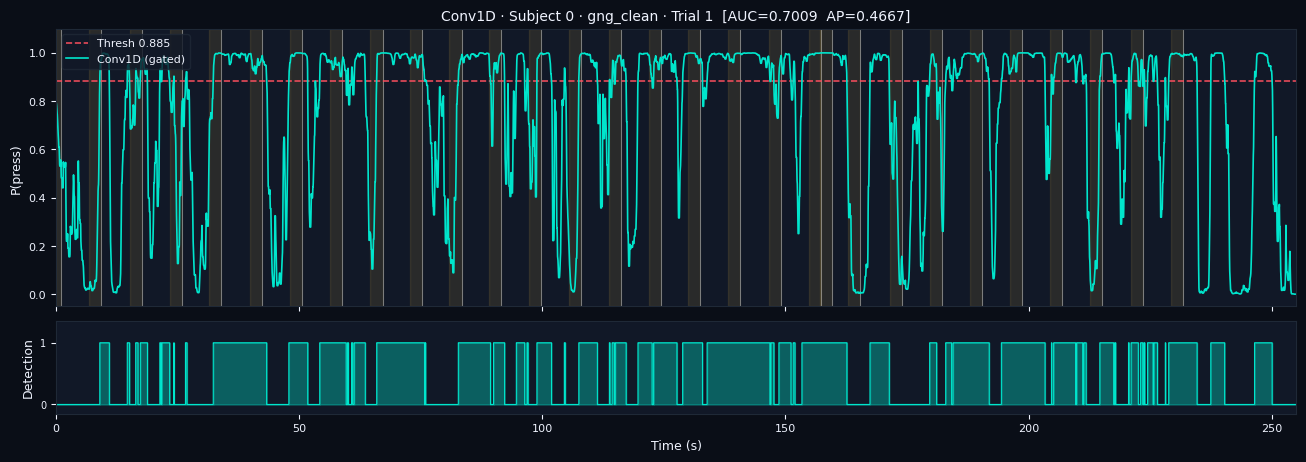

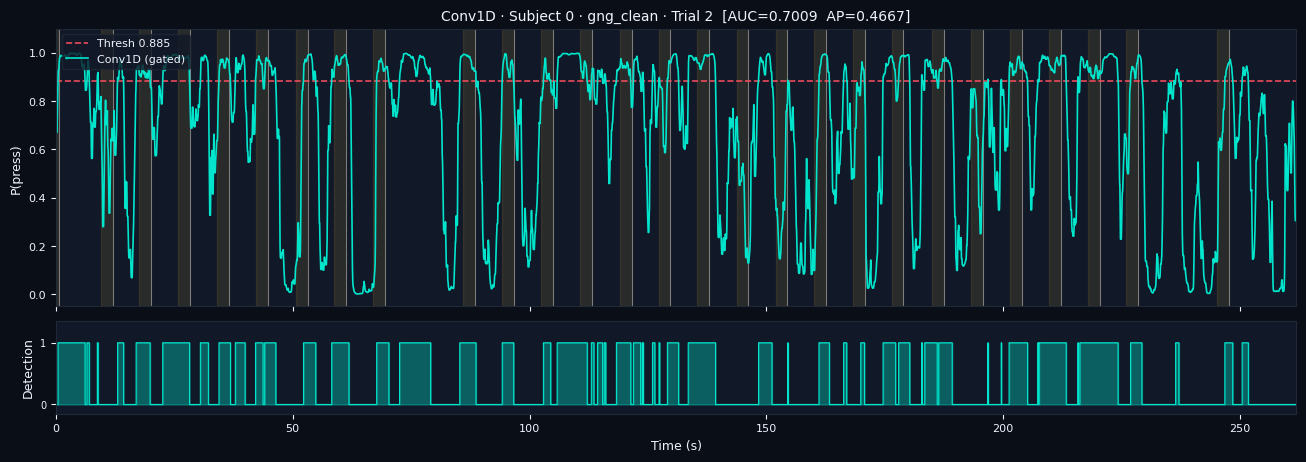

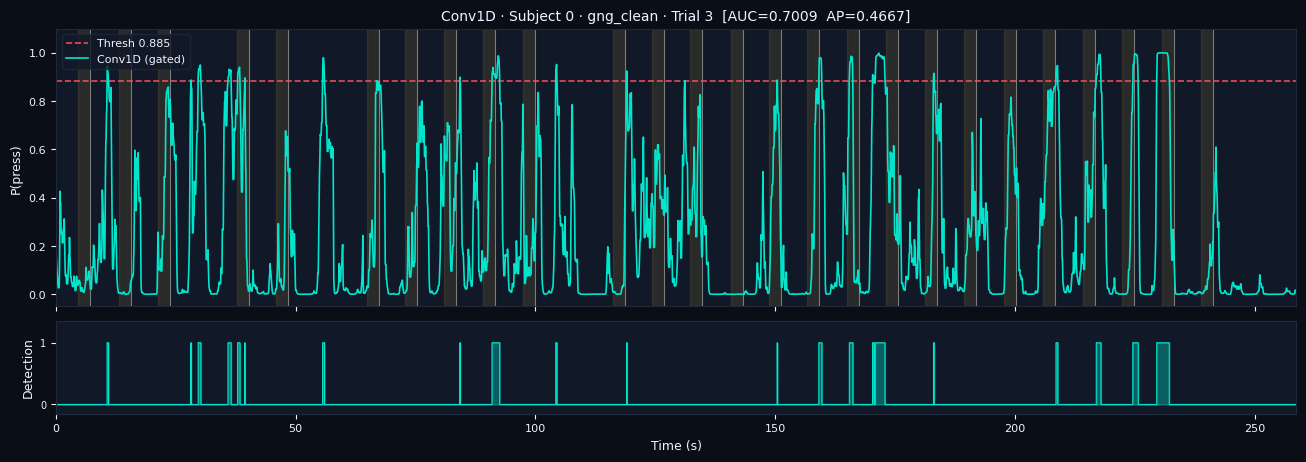

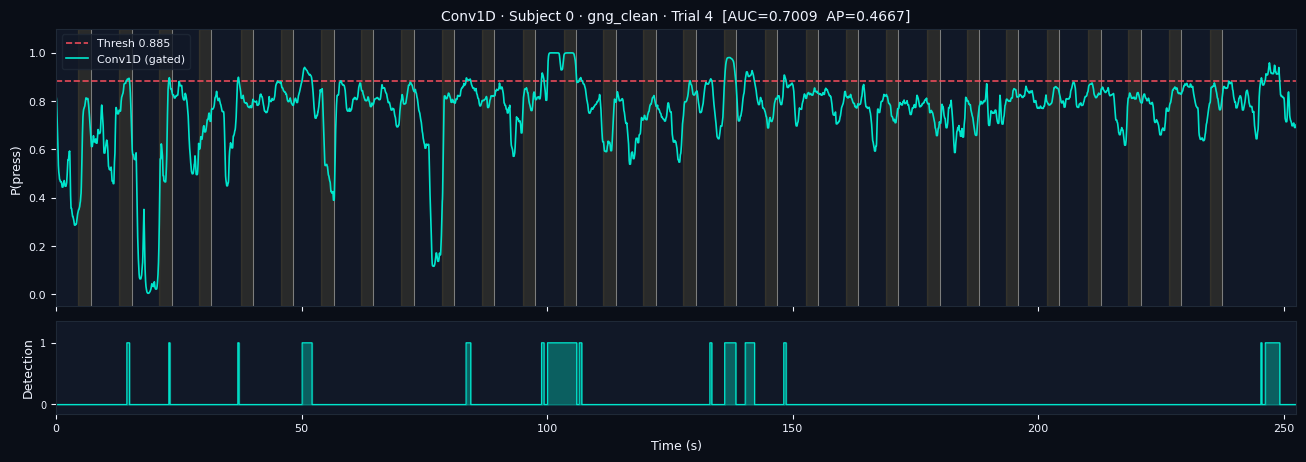

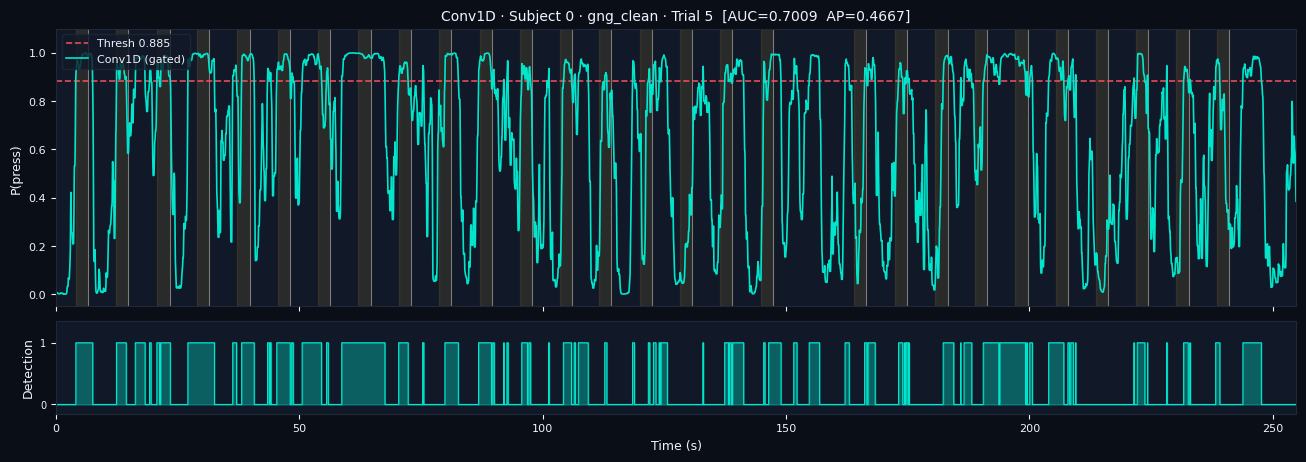

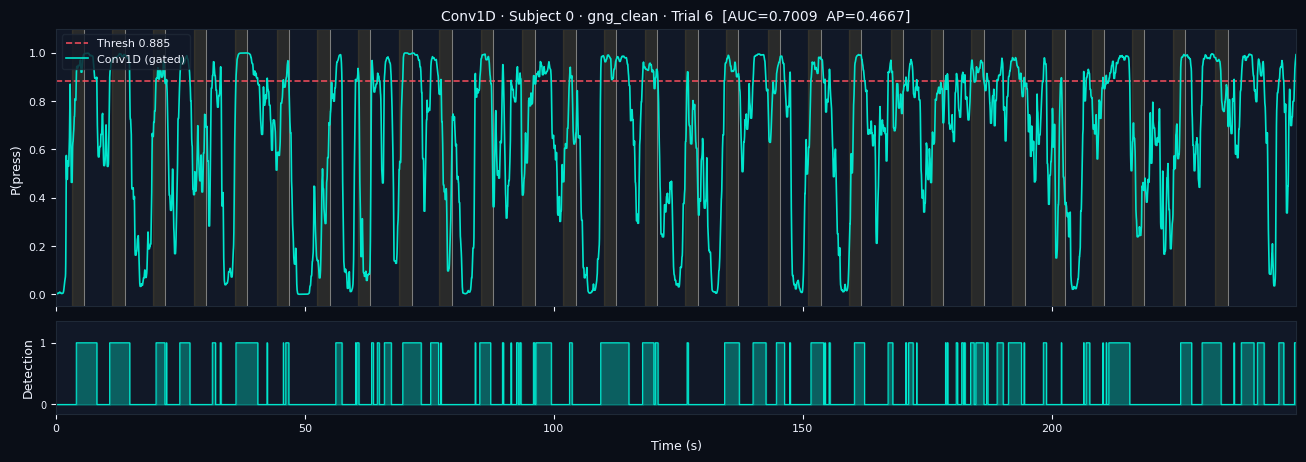

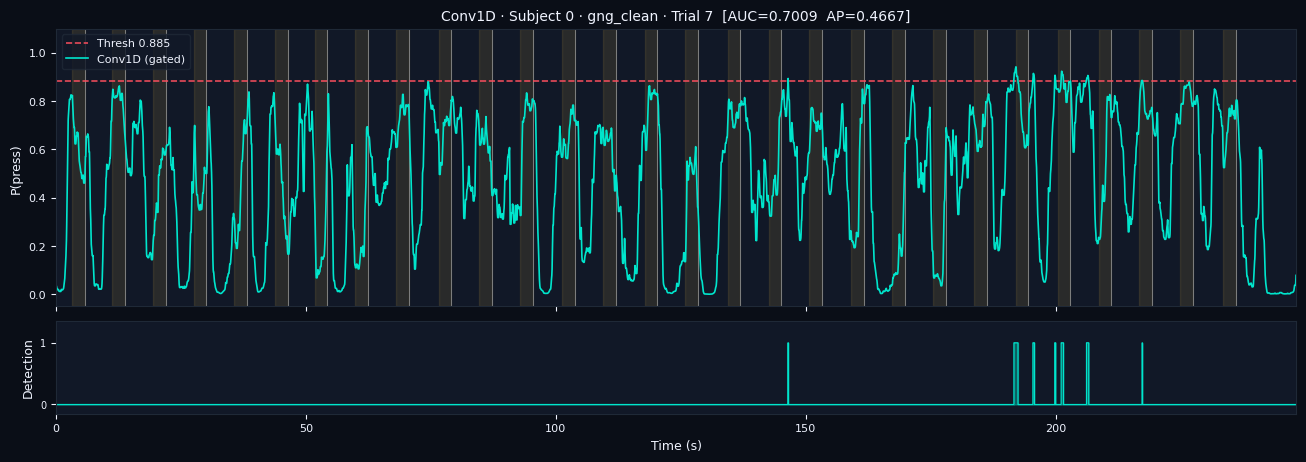

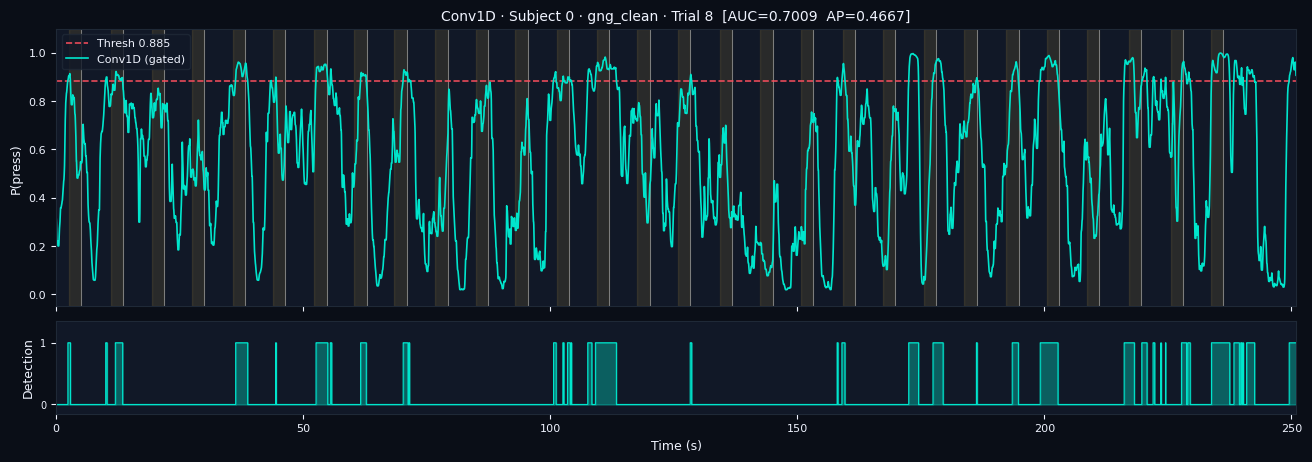

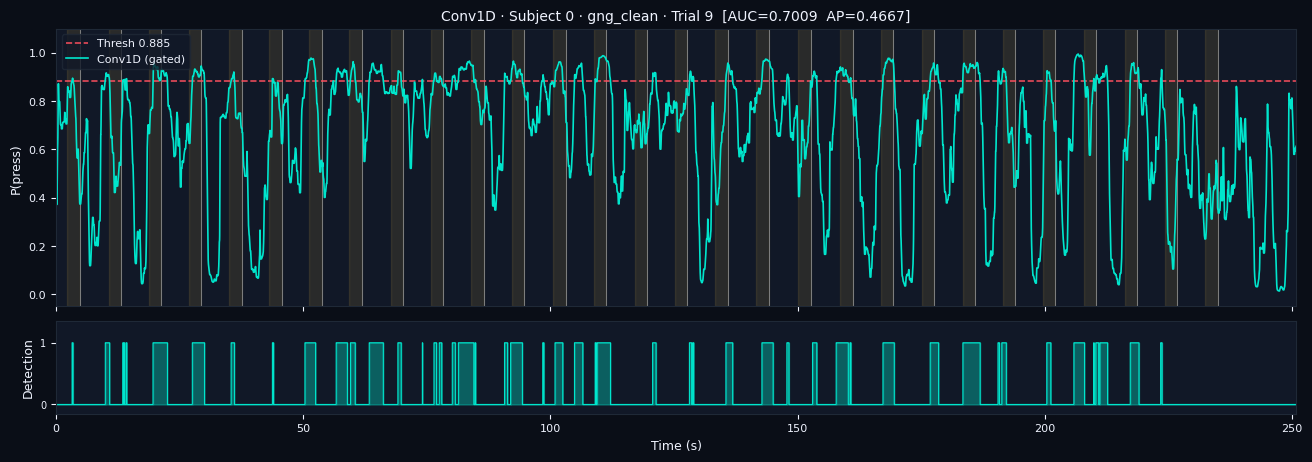

In [20]:
# ── Score timeline (last test trial) ─────────────────────────────────────────
for PLOT_TRIAL in TEST_TRIALS:

    m = tid_all == PLOT_TRIAL
    sc = scores_gated[m]
    ymom = ymom_all[m]
    t_ax = np.arange(len(sc)) / FS_EFF
    press_onsets = np.where(ymom > 0)[0]
    preds = (sc >= thresh_final).astype(int)
    
    fig, (ax_p, ax_d) = plt.subplots(
        2,
        1,
        figsize=(16, 5),
        facecolor=DARK,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08},
        sharex=True,
    )
    for ax in (ax_p, ax_d):
        ax.set_facecolor(CARD)
        for sp in ax.spines.values():
            sp.set_color(EDGE)
        ax.tick_params(colors=WHITE, labelsize=8)
    
    # Score panel
    ax_p.set_xlim(0, t_ax[-1])
    ax_p.set_ylim(-0.05, 1.1)
    ax_p.set_ylabel("P(press)", color=WHITE, fontsize=9)
    ax_p.tick_params(labelbottom=False)
    for onset in press_onsets:
        pt = onset / FS_EFF
        ax_p.axvspan(max(0, pt - HORIZON / FS_EFF), pt, alpha=0.10, color=GOLD)
        ax_p.axvline(pt, color=WHITE, lw=0.7, alpha=0.4)
    ax_p.axhline(
        thresh_final,
        color=CORAL,
        lw=1.2,
        ls="--",
        alpha=0.9,
        label=f"Thresh {thresh_final:.3f}",
    )
    ax_p.plot(t_ax, sc, color=TEAL, lw=1.2, label="Conv1D (gated)")
    ax_p.legend(
        facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8, loc="upper left"
    )
    ax_p.set_title(
        f"Conv1D · Subject {SUBJECT} · {TACHE} · Trial {PLOT_TRIAL}  "
        f'[AUC={fold_results[-1]["auc"]:.4f}  '
        f'AP={fold_results[-1]["ap"]:.4f}]',
        color=WHITE,
        fontsize=10,
    )
    
    # Binary detection panel
    ax_d.fill_between(t_ax, preds, step="post", color=TEAL, alpha=0.35)
    ax_d.step(t_ax, preds, color=TEAL, lw=0.8, where="post")
    ax_d.set_ylim(-0.15, 1.35)
    ax_d.set_yticks([0, 1])
    ax_d.set_yticklabels(["0", "1"], color=WHITE, fontsize=7)
    ax_d.set_ylabel("Detection", color=WHITE, fontsize=9)
    ax_d.set_xlabel("Time (s)", color=WHITE, fontsize=9)
    
    plt.tight_layout()